In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv("/content/archive.zip")

In [15]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)


In [26]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [56]:
# there are only two categorical data that is geography and the gender and these don't have any order so we will use the one hot encoding .
pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int) # by default , we are getting the boolean value that's why i used dtype=int .

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [66]:
x=df.drop(columns=['Exited'])
y=df['Exited']

# Apply one-hot encoding to categorical features in x
x = pd.get_dummies(x, columns=['Geography','Gender'], drop_first=True, dtype=int)

In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [60]:
x_train.shape

(8000, 11)

In [47]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler=StandardScaler()

In [63]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [64]:
x_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [68]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [69]:
# Initialize the ANN
classifier = Sequential()

In [71]:
# Add the input layer and the first hidden layer
classifier.add(Dense(units=6, activation='relu', input_dim=x_train_scaled.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
# Add the second hidden layer
classifier.add(Dense(units=6, activation='relu'))

In [73]:
# Add the output layer
classifier.add(Dense(units=1, activation='sigmoid'))

In [74]:
# Compile the ANN
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [75]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [91]:
history=classifier.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8666 - loss: 0.3295 - val_accuracy: 0.8494 - val_loss: 0.3430
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8677 - loss: 0.3293 - val_accuracy: 0.8519 - val_loss: 0.3421
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8661 - loss: 0.3292 - val_accuracy: 0.8506 - val_loss: 0.3426
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8670 - loss: 0.3289 - val_accuracy: 0.8519 - val_loss: 0.3421
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8675 - loss: 0.3288 - val_accuracy: 0.8556 - val_loss: 0.3413
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3287 - val_accuracy: 0.8494 - val_loss: 0.3433
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8670 - loss: 0.3287 - val_accuracy: 0.8544 - val_loss: 0.3420
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8673 - loss: 0.3285 - val_accu

In [92]:
history.history

{'accuracy': [0.8665624856948853,
  0.8676562309265137,
  0.8660937547683716,
  0.8670312762260437,
  0.8675000071525574,
  0.8670312762260437,
  0.8670312762260437,
  0.8673437237739563,
  0.8668749928474426,
  0.8653125166893005,
  0.8665624856948853,
  0.8659374713897705,
  0.8657812476158142,
  0.8665624856948853,
  0.8659374713897705,
  0.8665624856948853,
  0.8657812476158142,
  0.8675000071525574,
  0.8670312762260437,
  0.8660937547683716,
  0.8667187690734863,
  0.8662499785423279,
  0.8667187690734863,
  0.8668749928474426,
  0.8660937547683716,
  0.8660937547683716,
  0.8673437237739563,
  0.8675000071525574,
  0.8656250238418579,
  0.8660937547683716,
  0.8662499785423279,
  0.8651562333106995,
  0.8660937547683716,
  0.8657812476158142,
  0.8662499785423279,
  0.866406261920929,
  0.866406261920929,
  0.8659374713897705,
  0.8657812476158142,
  0.8665624856948853,
  0.8660937547683716,
  0.8653125166893005,
  0.8648437261581421,
  0.8645312786102295,
  0.8656250238418579,


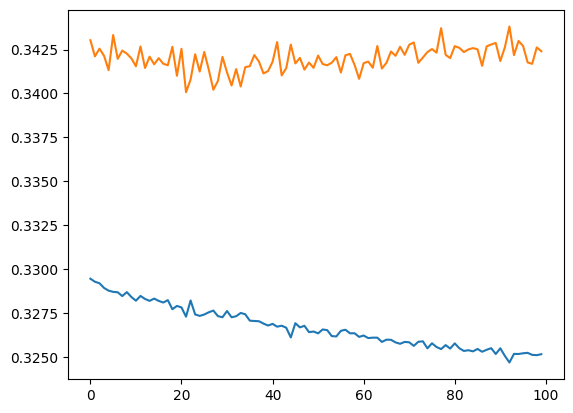

In [94]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

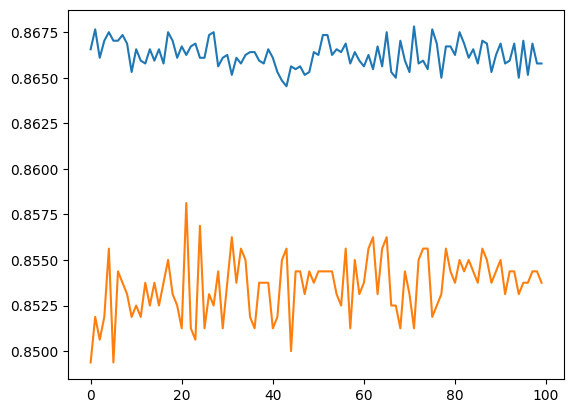

In [95]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [86]:
classifier.layers[0].get_weights()

[array([[-1.18029013e-01,  5.56217171e-02,  5.20574264e-02,
         -1.67762786e-02,  2.48079617e-02,  5.75112179e-02],
        [-2.75594175e-01,  5.60530126e-01, -9.92647588e-01,
         -5.46271086e-01, -1.34748667e-01, -1.93293780e-01],
        [-1.21177556e-02,  1.75507918e-01, -7.25476965e-02,
         -2.84788255e-02,  4.43841331e-02, -1.11336581e-01],
        [ 1.28036380e+00,  2.76889473e-01,  1.19999275e-01,
          2.51273364e-01, -6.12140775e-01,  6.77448928e-01],
        [ 1.49132386e-01, -1.42854333e-01,  1.13410056e-01,
          9.89800394e-02,  1.27870810e+00,  1.33149385e+00],
        [-2.09142901e-02,  2.30828971e-01,  7.72285601e-03,
         -1.07238367e-01, -2.78871227e-02, -5.45190908e-02],
        [ 1.42616898e-01,  1.16925049e+00, -4.09024537e-01,
          2.43432224e-01,  1.84951067e-01, -2.93948743e-02],
        [-9.91719812e-02,  1.07909329e-01,  4.12462950e-02,
         -3.68746012e-01,  4.33768670e-04, -1.27483502e-01],
        [-7.41841912e-01, -1.961

In [87]:
output =classifier.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [88]:
y_pred=np.where(output>0.5,1,0)

In [89]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [90]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.862